### Key Function For Descriptive statistics

* d.describe()
* df['col'].value_counts()
* df.quantile(q)
* skewness
* kurtosis
### quantiles and skewness

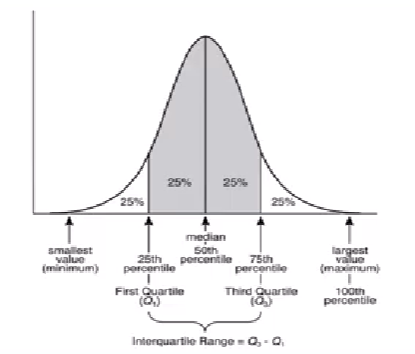


### right skewed distribution
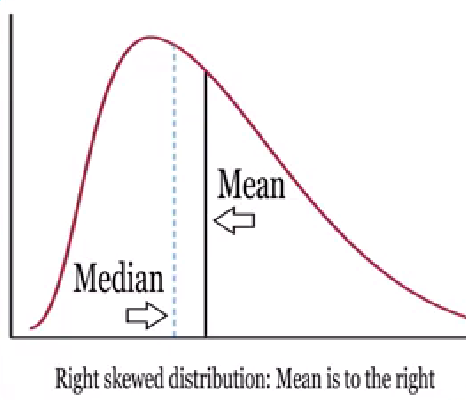

In [1]:
import numpy as np
import pandas as pd

# Set a random seed for reproducible results
np.random.seed(42)

n_rows = 1000

categories = ["Beauty", "Clothing", "Electronics", "Home"]
data = {
    "Order ID": [f"ORD-{1000 + i}" for i in range(n_rows)],
    "Order Date": pd.date_range(start="2023-01-01", periods=n_rows, freq="D"),
    "Product Category": np.random.choice(categories, size=n_rows),
    "Unit Price": np.random.uniform(10.0, 500.0, size=n_rows).round(2),
    "Quantity": np.random.randint(1, 10, size=n_rows),
}

df = pd.DataFrame(data)

# Calculate Revenue column based on Unit Price and Quantity
df["Revenue"] = (df["Unit Price"] * df["Quantity"]).round(2)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1000, 6)
   Order ID Order Date Product Category  Unit Price  Quantity  Revenue
0  ORD-1000 2023-01-01      Electronics      352.10         2   704.20
1  ORD-1001 2023-01-02             Home      272.69         6  1636.14
2  ORD-1002 2023-01-03           Beauty      161.67         5   808.35
3  ORD-1003 2023-01-04      Electronics      408.76         9  3678.84
4  ORD-1004 2023-01-05      Electronics      345.52         5  1727.60


In [2]:
# 1. Basic Descriptive Statistics
print("=== Descriptive Statistics ===")
print(df.describe())

# 2. Value Counts for Categorical Column
print("\n=== Value Counts ===")
print(df["Product Category"].value_counts())

# 3. Quantiles for Revenue (25%, 50%, 75%)
q1 = df["Revenue"].quantile(0.25)
q2 = df["Revenue"].quantile(0.50)  # Median
q3 = df["Revenue"].quantile(0.75)

print("\n=== Quantiles ===")
print(f"25th Percentile (Q1): {q1:.2f}")
print(f"50th Percentile (Q2 / Median): {q2:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")

# 4. Mean, Median, and Skewness
mean_rev = df["Revenue"].mean()
median_rev = df["Revenue"].median()
skew_rev = df["Revenue"].skew()

print("\n=== Central Tendency & Skewness ===")
print(f"Mean Revenue: {mean_rev:.2f}")
print(f"Median Revenue: {median_rev:.2f}")
print(f"Skewness: {skew_rev:.3f}")  # Positive = Right-skewed, Negative = Left-skewed

# 5. Grouped Analysis by Product Category
print("\n=== Mean Revenue by Product Category ===")
print(df.groupby("Product Category")["Revenue"].mean())

# 6. Interquartile Range (IQR) Calculation
iqr = q3 - q1
print("\n=== Interquartile Range (IQR) ===")
print(f"IQR: {iqr:.2f}")

# Verification checks
print("\n=== Logical Verifications ===")
print(f"Is Q3 > Q1? {q3 > q1}")
print(f"Is IQR > 0? {iqr > 0}")

=== Descriptive Statistics ===
                Order Date   Unit Price    Quantity      Revenue
count                 1000  1000.000000  1000.00000  1000.000000
mean   2024-05-14 12:00:00   254.879690     5.03600  1251.019820
min    2023-01-01 00:00:00    12.270000     1.00000    12.420000
25%    2023-09-07 18:00:00   126.095000     3.00000   450.282500
50%    2024-05-14 12:00:00   255.270000     5.00000   960.475000
75%    2025-01-19 06:00:00   377.367500     7.00000  1852.992500
max    2025-09-26 00:00:00   499.860000     9.00000  4440.510000
std                    NaN   142.982197     2.54385   995.632841

=== Value Counts ===
Product Category
Home           280
Beauty         258
Electronics    232
Clothing       230
Name: count, dtype: int64

=== Quantiles ===
25th Percentile (Q1): 450.28
50th Percentile (Q2 / Median): 960.48
75th Percentile (Q3): 1852.99

=== Central Tendency & Skewness ===
Mean Revenue: 1251.02
Median Revenue: 960.48
Skewness: 0.978

=== Mean Revenue by Product 

In [3]:
# Save to CSV file
df.to_csv("pandas_dummy_data.csv", index=False)

In [4]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Generate 1,000 orders across dates in 2022 and 2023
date_range = pd.date_range(start="2022-01-01", end="2023-12-31", freq="D")
random_dates = np.sort(np.random.choice(date_range, size=1000))

data = {
    "Order Date": random_dates,
    "Order ID": [f"ORD-{1000 + i}" for i in range(1000)],
    "Product Category": np.random.choice(
        ["Beauty", "Clothing", "Electronics", "Home"], size=1000
    ),
    "Unit Price": np.random.uniform(15.0, 300.0, size=1000).round(2),
    "Quantity": np.random.randint(1, 5, size=1000),
}

df = pd.DataFrame(data)
df["Revenue"] = (df["Unit Price"] * df["Quantity"]).round(2)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1000, 6)
  Order Date  Order ID Product Category  Unit Price  Quantity  Revenue
0 2022-01-01  ORD-1000           Beauty      284.13         3   852.39
1 2022-01-01  ORD-1001           Beauty       44.13         2    88.26
2 2022-01-01  ORD-1002           Beauty      258.45         3   775.35
3 2022-01-02  ORD-1003      Electronics      165.20         1   165.20
4 2022-01-02  ORD-1004      Electronics      250.39         4  1001.56


In [16]:
import numpy as np
import pandas as pd

# Safe index assignment (won't crash on reruns)
if "Order Date" in df.columns:
    df = df.set_index("Order Date")

print("=== Index Set to Datetime ===")
print(df.head())

# 2. Resample Data to Monthly Totals
monthly_revenue = df["Revenue"].resample("ME").sum()

print("\n=== Monthly Resampled Revenue (Sum) ===")
print(monthly_revenue.head())

# 3. Calculate Percentage Change Month-over-Month
monthly_pct_change = monthly_revenue.pct_change()

print("\n=== Percentage Change in Revenue Month-over-Month ===")
print(monthly_pct_change.head())

# 4. Sanity Check 1: Monotonicity Check on Index
is_increasing = df.index.is_monotonic_increasing
print("\n=== Sanity Check: Is Index Monotonically Increasing? ===")
print(is_increasing)

# 5. Sanity Check 2: Sum Validation
total_raw_revenue = df["Revenue"].sum()
total_monthly_revenue = monthly_revenue.sum()

is_equal = np.isclose(total_raw_revenue, total_monthly_revenue)

print("\n=== Sanity Check: Resampled Revenue Sum vs. Raw Revenue Sum ===")
print(f"Raw Revenue Total: {total_raw_revenue:.2f}")
print(f"Monthly Summed Total: {total_monthly_revenue:.2f}")
print(f"Do totals match? {is_equal}")

=== Index Set to Datetime ===
            Order ID Product Category  Unit Price  Quantity  Revenue
Order Date                                                          
2022-01-01  ORD-1000           Beauty      284.13         3   852.39
2022-01-01  ORD-1001           Beauty       44.13         2    88.26
2022-01-01  ORD-1002           Beauty      258.45         3   775.35
2022-01-02  ORD-1003      Electronics      165.20         1   165.20
2022-01-02  ORD-1004      Electronics      250.39         4  1001.56

=== Monthly Resampled Revenue (Sum) ===
Order Date
2022-01-31    19886.43
2022-02-28    19822.75
2022-03-31    14457.53
2022-04-30    19437.34
2022-05-31    13698.16
Freq: ME, Name: Revenue, dtype: float64

=== Percentage Change in Revenue Month-over-Month ===
Order Date
2022-01-31         NaN
2022-02-28   -0.003202
2022-03-31   -0.270660
2022-04-30    0.344444
2022-05-31   -0.295266
Freq: ME, Name: Revenue, dtype: float64

=== Sanity Check: Is Index Monotonically Increasing? ===
T

In [18]:
print("Today work is complete!!!!")

Today work is complete!!!!
